In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('trend_by_year_and_product.csv')

In [3]:
data

,product_code,YEAR,num_complaints,num_recalls
0,OCE,2017,6,0
1,NBW,2015,60955,0
2,MQP,2015,258,0
3,MHY,2015,3053,1
4,NDN,2015,202,0
...,...,...,...,...
22553,NDW,2025,4,0
22554,HCI,2025,1,0
22555,PFA,2025,3,0
22556,NOC,2025,1,0


In [4]:
data.shape

(22558, 4)

Logistic Regression Predicting Recall (From Current Year Data)

In [5]:
X = data[['num_complaints','YEAR']]

In [6]:
data['Recall'] = (data['num_recalls'] > 0).astype(int)

y = data['Recall']

#binary variable

In [7]:
X = data[['num_complaints','YEAR']]
y = data['Recall']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(class_weight='balanced') #more emphasis on recall cases 
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
from sklearn.metrics import classification_report, roc_auc_score

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, preds))
print("AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.80      0.95      0.87      3450
           1       0.59      0.22      0.32      1062

    accuracy                           0.78      4512
   macro avg       0.69      0.59      0.59      4512
weighted avg       0.75      0.78      0.74      4512

AUC: 0.7292640355904911


In [9]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef_df)

          Feature  Coefficient
0  num_complaints     0.000173
1            YEAR    -0.000048


Predicting Next-Year Recalls

In [10]:
data = data.sort_values(['product_code','YEAR'])

data['recall_next_year'] = (
    data.groupby('product_code')['num_recalls']
        .shift(-1)
)

data['Recall_next_year'] = (data['recall_next_year'] > 0).astype(int)

In [11]:
data = data.dropna(subset=['recall_next_year'])

In [12]:
X_1 = data[['num_complaints','YEAR']]
y_1= data['Recall_next_year']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_1, y_1, test_size=0.2, random_state=42
)

model_ny = LogisticRegression(class_weight='balanced')
model_ny.fit(X_train_1, y_train_1)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
preds_1 = model.predict(X_test_1)
probs_1 = model.predict_proba(X_test_1)[:,1]

print(classification_report(y_test_1, preds_1))
print("AUC:", roc_auc_score(y_test_1, probs_1))

              precision    recall  f1-score   support

           0       0.78      0.95      0.86      2803
           1       0.61      0.23      0.33       964

    accuracy                           0.77      3767
   macro avg       0.70      0.59      0.60      3767
weighted avg       0.74      0.77      0.72      3767

AUC: 0.7057940662272046


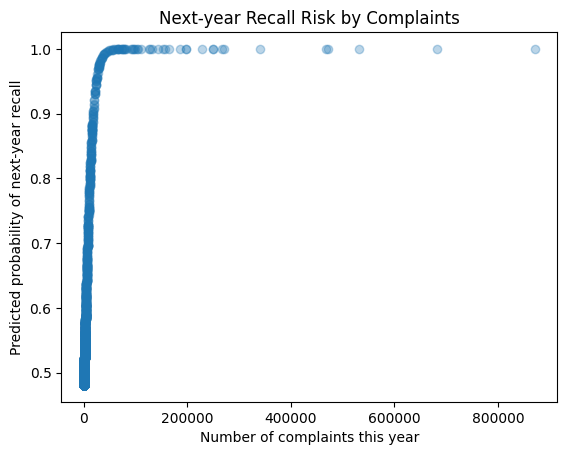

In [14]:
data['pred_prob'] = model.predict_proba(X_1)[:,1]

plt.scatter(data['num_complaints'], data['pred_prob'], alpha=0.3)
plt.xlabel("Number of complaints this year")
plt.ylabel("Predicted probability of next-year recall")
plt.title("Next-year Recall Risk by Complaints")
plt.show()

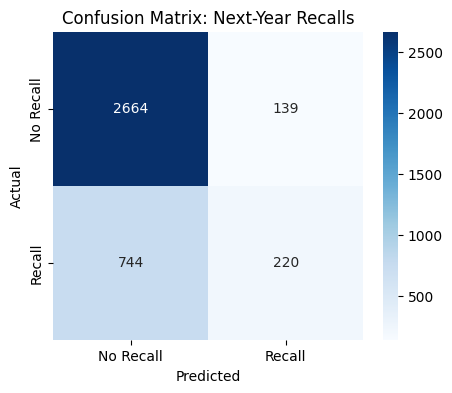

[[2664  139]
 [ 744  220]]


In [30]:
cm = confusion_matrix(y_test_1, preds_1)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Recall','Recall'], yticklabels=['No Recall','Recall'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Next-Year Recalls")
plt.show()

print(cm)

interpretation: 

- model predicts ~23% of next-year recalls correctly
- when recall is predicted, it is correct ~61% of the time
- most non-recall products are classified correctly (~95%)
- model improvement: feature engineering 

Current Recall Confusion Matrix

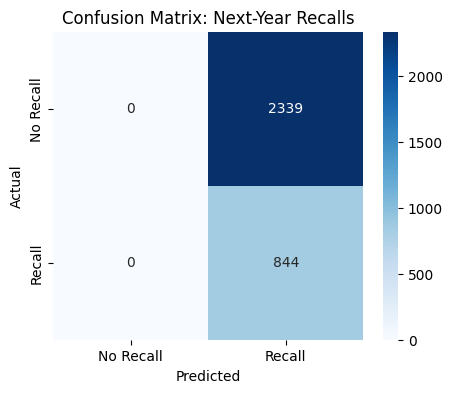

[[   0 2339]
 [   0  844]]


In [23]:
cm_1 = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Recall','Recall'], yticklabels=['No Recall','Recall'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Next-Year Recalls")
plt.show()

print(cm_1)